# 多模态大模型实验一：调用前沿大模型 API 进行多模态交互任务

## 实验准备

In [2]:
!pip3 install requests pillow pytesseract openai

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.2 MB 58 kB/s eta 0:00:012
     |████████████████████████████████| 315 kB 63 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [1]:
from openai import OpenAI
from IPython.display import display
import requests
from PIL import Image
from io import BytesIO

/Users/qileizhou/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


把申请的api key填写在下面的位置

In [2]:
#填写key信息
client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key="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", # put your api key here.
)

## OCR任务

描述：从图像中提取文字。


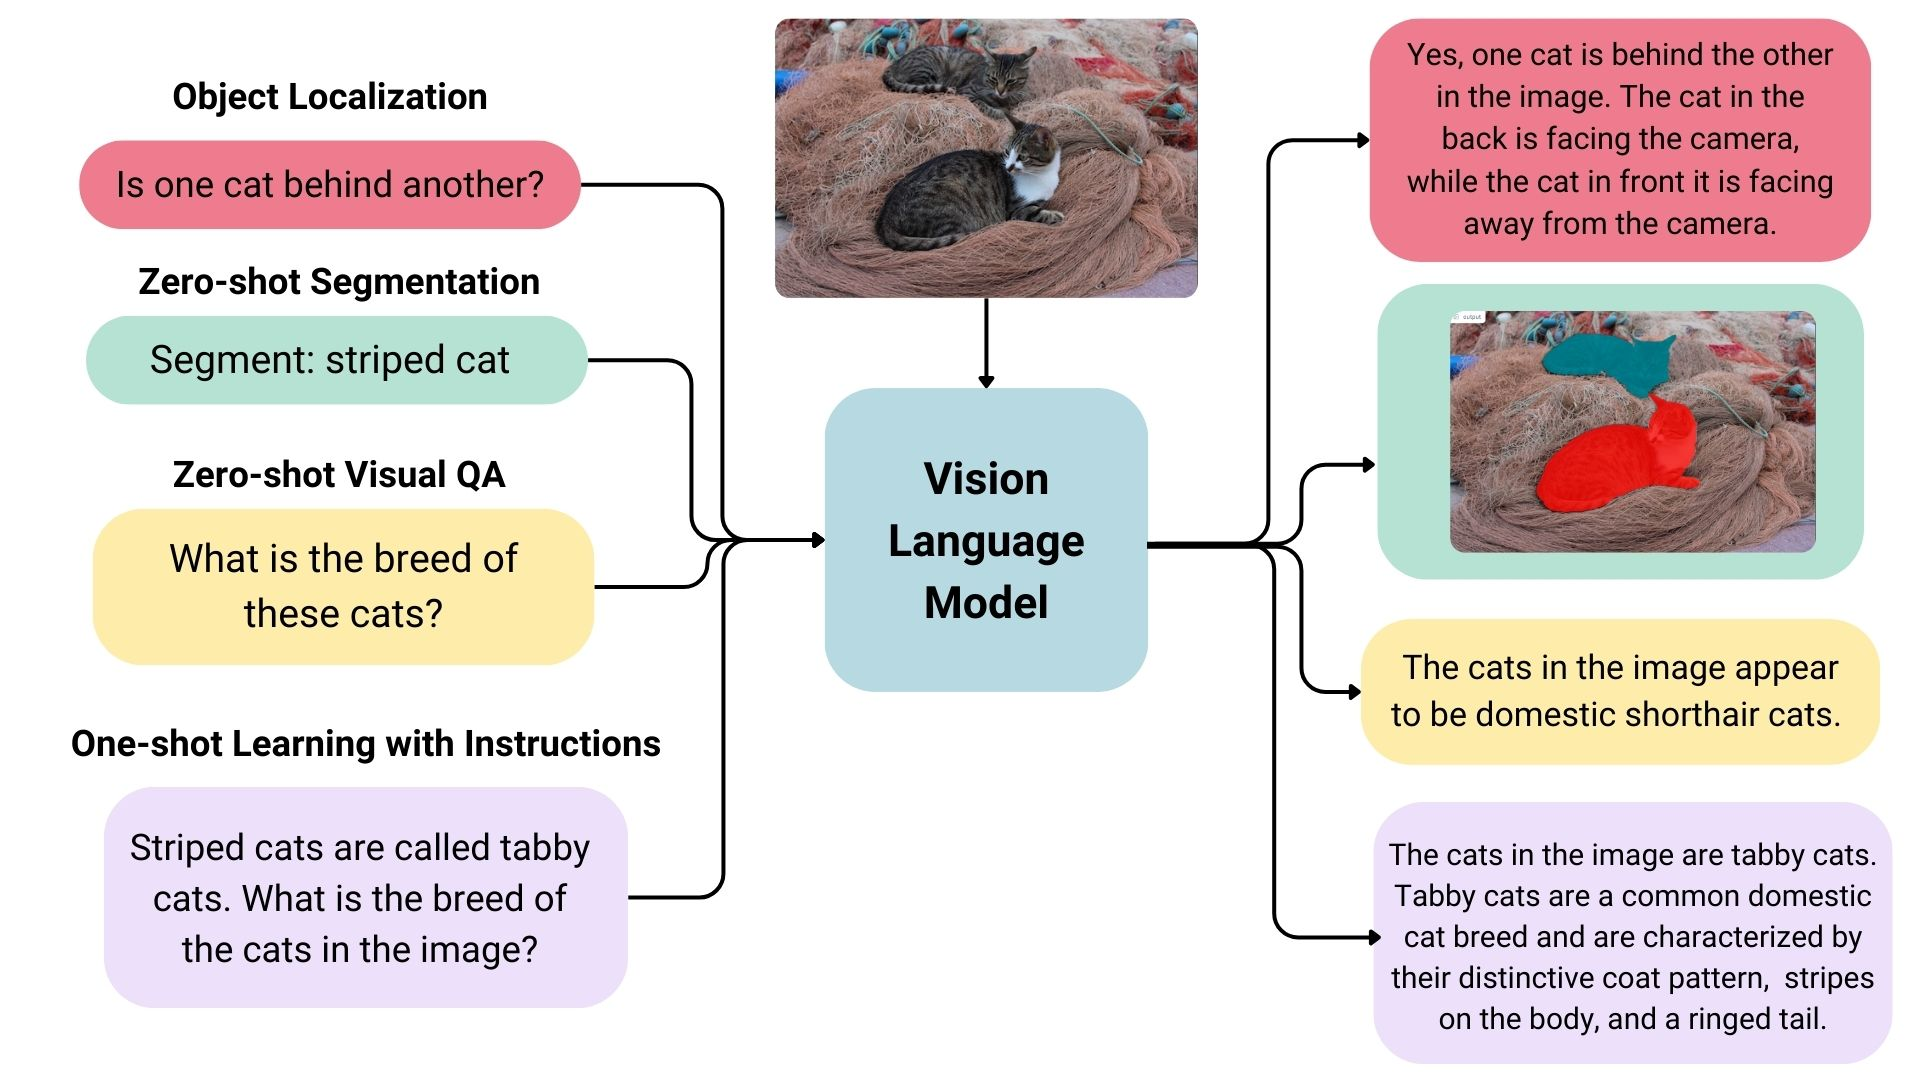

In [5]:
# 在线显示图片
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/blog/vlm/visual.jpg"
display(Image.open(BytesIO(requests.get(image_url).content)))

In [6]:
# 调用多模态大模型API进行文字识别
completion = client.chat.completions.create(
  extra_body={},
  model="google/gemma-4-26b-a4b-it:free",
  messages=[
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "Please recognize and extract the text from this image."
        },
        {
          "type": "image_url",
          "image_url": {
            "url": image_url
          }
        }
      ]
    }
  ]
)

In [7]:
print(completion.choices[0].message.content)

Object Localization
Is one cat behind another?

Zero-shot Segmentation
Segment: striped cat

Zero-shot Visual QA
What is the breed of these cats?

One-shot Learning with Instructions
Striped cats are called tabby cats. What is the breed of the cats in the image?

Vision Language Model

Yes, one cat is behind the other in the image. The cat in the back is facing the camera, while the cat in front it is facing away from the camera.

The cats in the image appear to be domestic shorthair cats.

The cats in the image are tabby cats. Tabby cats are a common domestic cat breed and are characterized by their distinctive coat pattern, stripes on the body, and a ringed tail.


## 图像字幕生成任务（Image Captioning）

生成自然语言描述图片内容

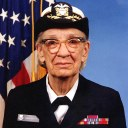

In [8]:
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display

# 换用一张没有任何限制的测试图片 (GitHub 上的图片)
image_url = "https://raw.githubusercontent.com/python-pillow/Pillow/main/Tests/images/hopper.jpg"

# 甚至不需要 headers 就能直接获取
response = requests.get(image_url)

if response.status_code == 200:
    img = Image.open(BytesIO(response.content))
    display(img)
else:
    print(f"图片获取失败，HTTP 状态码: {response.status_code}")

In [9]:
completion = client.chat.completions.create(
  extra_body={},
  model="google/gemma-4-26b-a4b-it:free",
  messages=[
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "Describe this image."
        },
        {
          "type": "image_url",
          "image_url": {
            "url": image_url
          }
        }
      ]
    }
  ]
)

In [10]:
print(completion.choices[0].message.content)

A head and shoulders, medium-shot portrait shows an elderly woman, likely in her 70s or 80s, in a dark blue military uniform and a matching peaked cap. She has short, light brown hair, wears clear-rimmed glasses, and looks directly into the camera with a small, closed-mouth smile. Her uniform features a white collar, a dark blue necktie, a silver nameplate on the right side of her chest, and several colorful ribbon bars on the left side of her chest. Behind her, on the left, is a portion of an American flag, and the background on the right is a solid blue. The lighting is even, and the focus is sharp on the woman's face.


## 视觉问答任务（Visual Question Answering, VQA）

允许用户对图像提出问题，并让模型回答，例如“这张图片里有多少只猫？”

正在下载图片，请稍候...


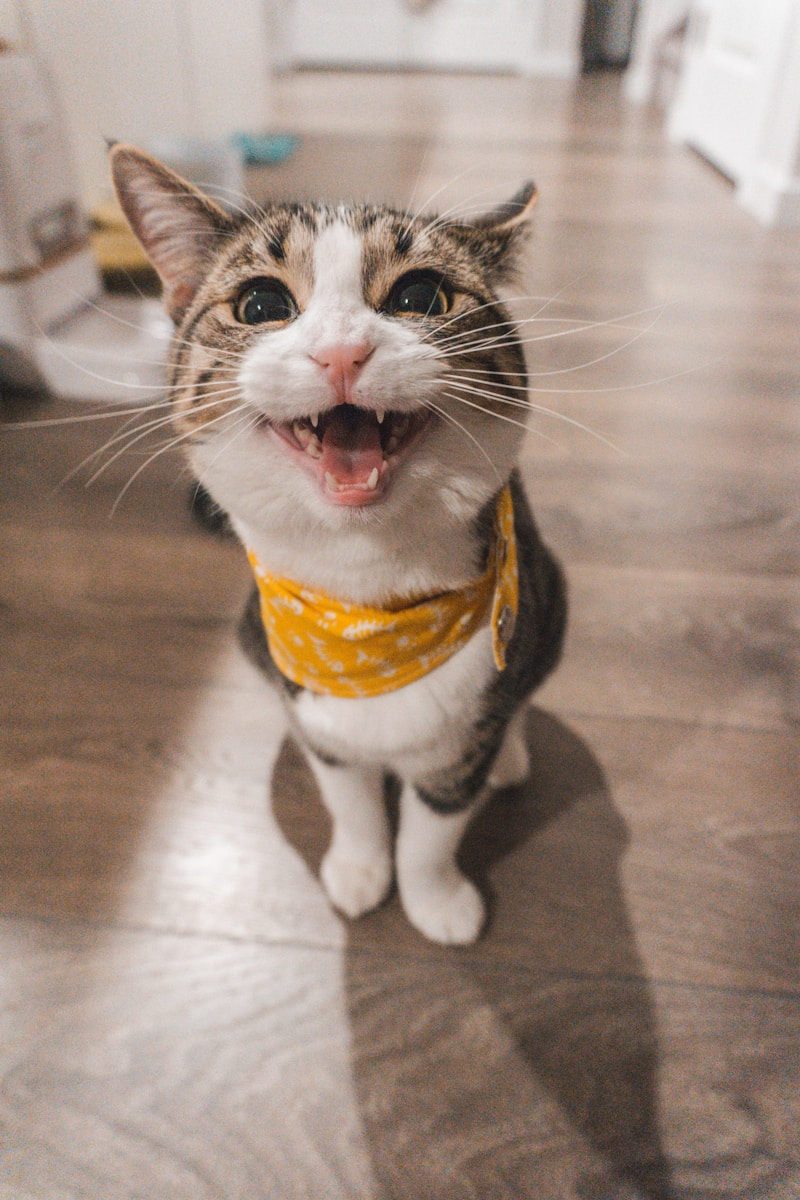

图片加载成功！


In [4]:
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display

# 这是一张包含猫咪的图片（Unsplash 高清图库）
image_url = "https://images.unsplash.com/photo-1543852786-1cf6624b9987?w=800"

# 伪装成真实的电脑浏览器，防止被拦截
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

print("正在下载图片，请稍候...")
try:
    response = requests.get(image_url, headers=headers)
    
    # 200 代表服务器成功返回了数据
    if response.status_code == 200:
        img = Image.open(BytesIO(response.content))
        display(img)
        print("图片加载成功！")
    else:
        print(f"获取图片失败，状态码：{response.status_code}")
        
except Exception as e:
    print(f"发生错误：{e}")

In [13]:
completion = client.chat.completions.create(
  extra_body={},
  model="google/gemma-4-26b-a4b-it:free",
  messages=[
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "Do you know who drew this painting?"
        },
        {
          "type": "image_url",
          "image_url": {
            "url": image_url
          }
        }
      ]
    }
  ]
)

In [14]:
print(completion.choices[0].message.content)

This is actually a photograph, not a painting! It is a photo of a very happy-looking cat wearing a yellow bandana.


In [5]:
completion = client.chat.completions.create(
  extra_body={},
  model="bytedance-seed/seed-1.6-flash",
  messages=[
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "这个小猫在干什么"
        },
        {
          "type": "image_url",
          "image_url": {
            "url": image_url
          }
        }
      ]
    }
  ]
)

print(completion.choices[0].message.content)

这只小猫张着嘴巴，露出牙齿，看起来像是在撒娇、发出可爱的叫声，或是在试图引起主人的注意。它的表情和姿态传递出一种活泼、亲昵的感觉，仿佛在以自己独特的方式与周围互动，显得十分灵动可爱。


# 附加实验

请基于本次实验，完成以下任务：

1、提供的代码是对一个多模态大模型进行测试。尝试增加对多种大模型的调用，并进行横向评估。

2、尝试设计更多的多模态任务，调用多模态大模型API完成


## 对于视觉问答任务尝试其他模型

In [26]:
completion = client.chat.completions.create(
  extra_body={},
  model="bytedance-seed/seed-1.6-flash",
  messages=[
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "Do you know who drew this painting?"
        },
        {
          "type": "image_url",
          "image_url": {
            "url": image_url
          }
        }
      ]
    }
  ]
)

In [27]:
print(completion.choices[0].message.content)

The image you provided appears to be a **photograph** (not a painting or drawing) of a cat. Without additional context, metadata, or clear attribution, it's not possible to identify the specific photographer or artist who created this image. If it's a stock photo, you might check platforms like Shutterstock or Unsplash for similar images to trace its origin, but without more details, we can't determine the creator definitively.


If you meant to ask about the photographer, sharing more context (e.g., where you found the image) could help narrow it down!


## 视频内容描述

In [16]:
import requests
from IPython.display import display, Video
import os

# Your Bilibili video URL
video_url = "https://cn-gddg-ct-01-12.bilivideo.com/upgcxcode/25/78/378367825/378367825-1-16.mp4?e=ig8euxZM2rNcNbRVhwdVhwdlhWdVhwdVhoNvNC8BqJIzNbfq9rVEuxTEnE8L5F6VnEsSTx0vkX8fqJeYTj_lta53NCM%3D&gen=playurlv3&os=bcache&og=hw&oi=1782024106&platform=html5&mid=0&uipk=5&deadline=1776252045&nbs=1&trid=000080a89b7d518146baaf1081c5d77772ah&upsig=2fb9cf70ea9e599e596f34d91fc8bd3a&uparams=e,gen,os,og,oi,platform,mid,uipk,deadline,nbs,trid&cdnid=61312&bvc=vod&nettype=0&bw=431263&f=h_0_0&agrr=1&buvid=&build=0&dl=0&orderid=0,1"

# Save path
video_filename = "downloaded_video.mp4"

# Crucial: Bilibili requires a 'Referer' header to avoid 403 Forbidden errors
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Referer": "https://bilibili.com" 
}

print("Starting video download...")
try:
    # Use stream=True for large files to save memory
    response = requests.get(video_url, headers=headers, stream=True)
    
    if response.status_code == 200:
        with open(video_filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        
        print("Download complete! Displaying video...")
        
        # Display the video player in Jupyter
        # Note: 'embed=True' is needed for some environments to play local files
        display(Video(video_filename, width=600, embed=True))
        
    else:
        print(f"Failed to fetch video, Status Code: {response.status_code}")
        if response.status_code == 403:
            print("Hint: The link might have expired (check the 'deadline' in URL).")
            
except Exception as e:
    print(f"An error occurred: {e}")


Starting video download...
Download complete! Displaying video...


In [20]:
!pip3 install opencv-python

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 46.2 MB 340 kB/s eta 0:00:01
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-macos 2.13.1 requires numpy<=1.24.3,>=1.22, but you have numpy 2.0.2 which is incompatible.
tensorflow-macos 2.13.1 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.15.0 which is incompatible.
spleeter 2.3.2 requires httpx[http2]<0.20.0,>=0.19.0, but you have httpx 0.28.1 which is incompatible.
spleeter 2.3.2 requires librosa<0.9.0,>=0.8.0, but you have librosa 0.11.0 which is incompatible.
spleeter 2.3.2 requires llvm

In [25]:
import cv2
import base64
import requests

# 1. 提取视频帧并转为 Base64
def get_video_frames(video_path, max_frames=10):
    video = cv2.VideoCapture(video_path)
    base64_frames = []
    
    while video.isOpened():
        success, frame = video.read()
        if not success:
            break
        # 每隔 30 帧取一张（假设视频是 30fps，即每秒取一张）
        if int(video.get(cv2.CAP_PROP_POS_FRAMES)) % 30 == 0:
            _, buffer = cv2.imencode(".jpg", frame)
            base64_frames.append(base64.b64encode(buffer).decode("utf-8"))
        
        if len(base64_frames) >= max_frames:
            break
            
    video.release()
    return base64_frames

# 2. 准备数据
video_file = "downloaded_video.mp4"
frames = get_video_frames(video_file)

# 构建发送给 API 的 content 列表
content_list = [{"type": "text", "text": "请描述这个视频里发生了什么？"}]

for b64_img in frames:
    content_list.append({
        "type": "image_url",
        "image_url": {"url": f"data:image/jpeg;base64,{b64_img}"}
    })

# 3. 调用 API
completion = client.chat.completions.create(
  model="bytedance-seed/seed-1.6-flash", # 确保模型支持多图输入
  messages=[
    {
      "role": "user",
      "content": content_list
    }
  ]
)

print(completion.choices[0].message.content)


视频中展示了一只手操作一罐可口可乐（零度汽水）的过程：首先，手指捏住可乐罐的拉环部分，进行开启动作（从捏拉环到拉开拉环的过程），随后镜头展示了可乐罐的外观，清晰呈现“可口可乐 零度 汽水”的字样以及罐身细节。整体过程围绕开启可乐罐并展示其包装展开，突出了可口可乐零度汽水的产品形象。
